# 🥋 Poser — Advanced Exploratory Data Analysis
**Dataset:** `karate_normalized_base.csv`  
**Classes:** GedanBarai (下段払い) · Gyakudzuki (逆突き) · MaeGeri (前蹴り)  
**Preprocessing:** Translation-invariant (Mid-Hip origin) + Scale-invariant (÷ shoulder width)

---

### Notebook Overview

| Section | Purpose |
|---------|---------|
| § 1 | Class balance — are the three technique classes evenly represented? |
| § 2 | Data quality — missing values, infinite values, frame-count validation |
| § 3 | Upper vs lower body variance — key justification for the Dual-Stem architecture |
| § 4 | Angle feature distributions & correlation heatmap |
| § 5 | Temporal trajectories — how joint angles evolve across the 30-frame window |
| § 6 | Summary readiness report |

## ⚙️ Setup — Imports & Configuration

Loads all visualization libraries and defines the colour palette.  
`dark_background` matplotlib style + custom `BG_COLOR` keeps the visual identity consistent throughout the notebook.  
The CSV is read once here and reused in every section.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
plt.style.use('dark_background')
PALETTE   = {'GedanBarai': '#00C9FF', 'Gyakudzuki': '#FF6B6B', 'MaeGeri': '#A8FF78'}
BG_COLOR  = '#0D1117'
GRID_CLR  = '#21262D'
sns.set_theme(style='darkgrid', rc={'figure.facecolor': BG_COLOR, 'axes.facecolor': '#161B22'})

# ── Load Data ───────────────────────────────────────────────────────────────
# Update this path to wherever your CSV lives
CSV_PATH = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\data\karate_normalized_base.csv"
df = pd.read_csv(CSV_PATH)
print(f'✅ Loaded  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head(3)

import os
OUT_DIR = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\thesis_results"
os.makedirs(OUT_DIR, exist_ok=True)


✅ Loaded  →  13,380 rows  ×  149 columns


## § 1 — Clip-Level Class Balance

**Why clip-level and not frame-level?**  
Every clip is downsampled to exactly 30 frames. Counting raw rows would be misleading because it would simply reflect 30 × (number of clips). Instead, we count **unique `clip_id`s** to get the true data distribution.

- A **Coefficient of Variation (CV) < 0.15** is used as the balanced/imbalanced threshold.  
- Imbalanced datasets may require `class_weight` during training to avoid the model ignoring minority classes.

=== Clip-Level Class Balance ===
folder_label  num_clips
     MaeGeri        175
  Gyakudzuki        142
  GedanBarai        129

Total unique clips: 446


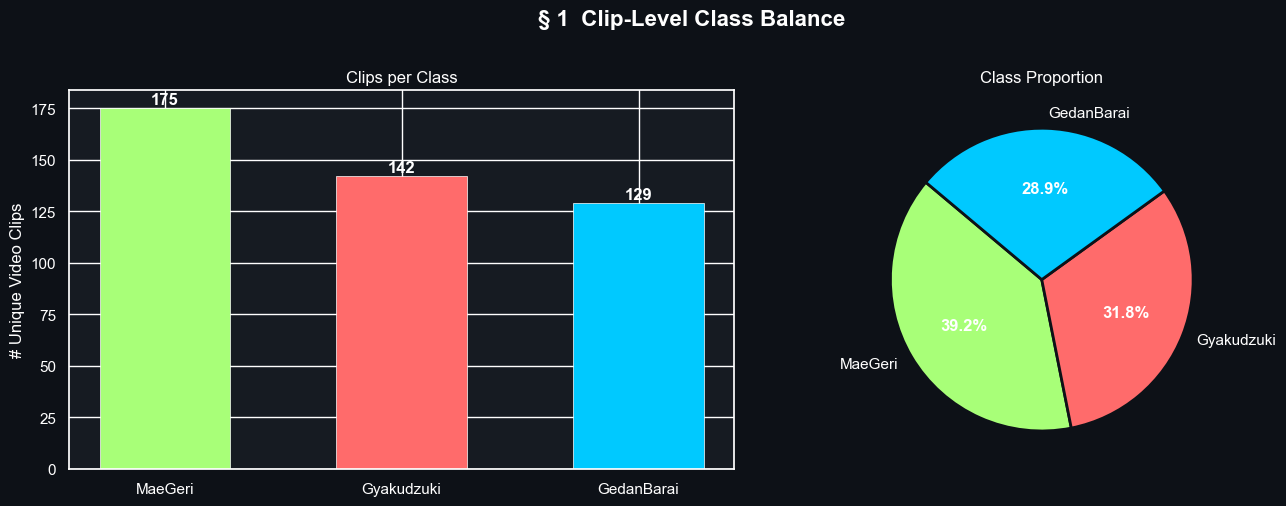


⚠️  Balance Assessment: IMBALANCED ⚠️ — consider class weighting


In [2]:
clip_balance = (
    df.drop_duplicates(subset=['clip_id'])
      .groupby('folder_label')['clip_id']
      .count()
      .reset_index()
      .rename(columns={'clip_id': 'num_clips'})
      .sort_values('num_clips', ascending=False)
)
print('=== Clip-Level Class Balance ===')
print(clip_balance.to_string(index=False))
total_clips  = clip_balance['num_clips'].sum()
clip_balance['pct'] = (clip_balance['num_clips'] / total_clips * 100).round(1)
print(f'\nTotal unique clips: {total_clips}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG_COLOR)
fig.suptitle('§ 1  Clip-Level Class Balance', fontsize=16, fontweight='bold', color='white', y=1.01)

colors = [PALETTE[lbl] for lbl in clip_balance['folder_label']]

# Bar chart
bars = axes[0].bar(clip_balance['folder_label'], clip_balance['num_clips'],
                   color=colors, edgecolor='white', linewidth=0.5, width=0.55)
axes[0].set_title('Clips per Class', color='white')
axes[0].set_ylabel('# Unique Video Clips', color='white')
axes[0].tick_params(colors='white')
for bar, val in zip(bars, clip_balance['num_clips']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', color='white', fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    clip_balance['num_clips'],
    labels=clip_balance['folder_label'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'color': 'white'},
    wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion', color='white')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sec1_class_balance.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('\n⚠️  Balance Assessment:', 'BALANCED ✅' if clip_balance['num_clips'].std() / clip_balance['num_clips'].mean() < 0.15 else 'IMBALANCED ⚠️ — consider class weighting')

## § 2 — Missing / Infinite Value Check

A clean baseline is critical before training. This cell checks for:

- **NaN values** — missing pose landmarks (e.g. occluded body parts).
- **Infinite values** — could arise from division by near-zero shoulder distances during normalisation.
- **Frame count validation** — every clip must have exactly 30 frames; any deviation means the downsampling step in `3_extract_angles.py` failed for that clip.

In [3]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if missing_cols.empty:
    print('✅ No missing values found!')
else:
    print(missing_cols)

print('\n=== Infinite Values ===')
num_df = df.select_dtypes(include=[np.number])
inf_mask = np.isinf(num_df)
inf_cols = inf_mask.sum()
inf_cols = inf_cols[inf_cols > 0]
if inf_cols.empty:
    print('✅ No infinite values found!')
else:
    print(inf_cols)

print('\n=== Basic Statistics (feature columns) ===')
print(num_df.describe().round(4))

print('\n=== Frame Count Validation ===')
frames_per_clip = df.groupby('clip_id')['frame_idx'].count()
print(f'Expected 30 frames per clip: {(frames_per_clip == 30).all()}')
if not (frames_per_clip == 30).all():
    bad = frames_per_clip[frames_per_clip != 30]
    print(f'⚠️ Clips with wrong frame count:\n{bad}')

=== Missing Values ===
✅ No missing values found!

=== Infinite Values ===
✅ No infinite values found!

=== Basic Statistics (feature columns) ===


        frame_idx    angle_00    angle_01    angle_02    angle_03    angle_04  \
count  13380.0000  13380.0000  13380.0000  13380.0000  13380.0000  13380.0000   
mean      15.5000      0.8101      0.8137      0.8758      0.8799      0.5714   
std        8.6558      0.1375      0.1336      0.1682      0.1485      0.1299   
min        1.0000      0.0019      0.0021      0.0005      0.0004      0.0005   
25%        8.0000      0.7208      0.7183      0.8447      0.8312      0.5123   
50%       15.5000      0.8235      0.8190      0.9372      0.9357      0.5637   
75%       23.0000      0.9228      0.9284      0.9757      0.9757      0.6371   
max       30.0000      0.9997      0.9997      0.9999      0.9998      0.9996   

         angle_05    angle_06    angle_07    angle_08  ...         z30  \
count  13380.0000  13380.0000  13380.0000  13380.0000  ...  13380.0000   
mean       0.5786      0.8795      0.8766      0.1188  ...      2.2005   
std        0.1311      0.1579      0.1412      0

## § 3 — Upper vs Lower Body Feature Variance (Boxplots)

This is the **core architectural justification** for the Dual-Stem model.

**Hypothesis:** Upper-body features (arms, shoulders, elbows) carry the discriminative signal for blocks and punches, while lower-body features (legs, knees, ankles) carry it for kicks.  
**Method:** For each clip, we compute the **mean feature variance** across its 30 frames — a proxy for "how much does this body region move during this technique?"

If the classes show *different* variance profiles in upper vs lower body, the Dual-Stem architecture — which processes them with separate BiLSTM streams — is empirically justified.

> **Feature split used throughout the project:**
> - **Upper:** landmarks 11–22 (shoulders → wrists) + angles 08–13 → **54 features**
> - **Lower:** landmarks 23–32 (hips → heels) + angles 00–07 → **48 features**

Upper features: 54  |  Lower features: 48



=== EXACT NUMERICAL VARIANCE ===
                           median       mean          max         std
track      folder_label                                              
Lower Body GedanBarai    2.059998  28.090653  2017.693592  180.331143
           Gyakudzuki    2.978615  25.381573  1957.907089  166.424833
           MaeGeri       2.516923  30.566033   654.987624   77.861091
Upper Body GedanBarai    2.145973  22.885803  1777.776059  157.138365
           Gyakudzuki    5.489282  52.935403  4980.330223  418.654417
           MaeGeri       1.230942  23.561186   930.725887   80.133484


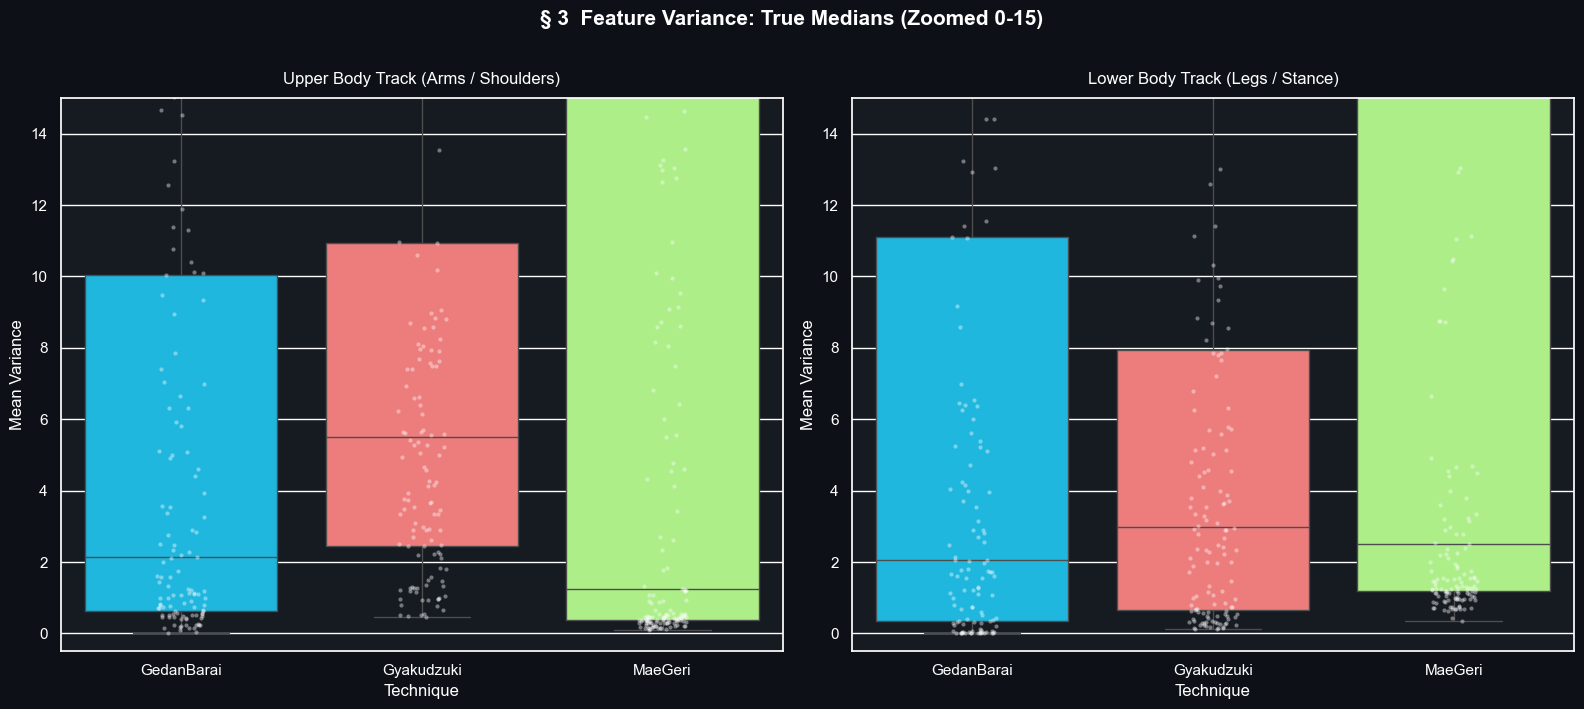

In [4]:
# ── Define feature groups ────────────────────────────────────────────────────
UPPER_COORDS = [f'{c}{i}' for i in range(11, 23) for c in ['x', 'y', 'z', 'v']]
UPPER_ANGLES = [f'angle_{i:02d}' for i in range(8, 14)]
UPPER_FEATS  = UPPER_COORDS + UPPER_ANGLES   # 48 + 6 = 54

LOWER_COORDS = [f'{c}{i}' for i in range(23, 33) for c in ['x', 'y', 'z', 'v']]
LOWER_ANGLES = [f'angle_{i:02d}' for i in range(0, 8)]
LOWER_FEATS  = LOWER_COORDS + LOWER_ANGLES   # 40 + 8 = 48

print(f'Upper features: {len(UPPER_FEATS)}  |  Lower features: {len(LOWER_FEATS)}')

# ── Compute per-clip VARIANCE for each feature, then average ──────────────
def clip_variance_df(feature_list, label):
    rows = []
    for clip, grp in df.groupby('clip_id'):
        cls = grp['folder_label'].iloc[0]
        var = grp[feature_list].var().mean()   # mean variance across features
        rows.append({'clip_id': clip, 'folder_label': cls, 'mean_variance': var, 'track': label})
    return pd.DataFrame(rows)

upper_var = clip_variance_df(UPPER_FEATS, 'Upper Body')
lower_var = clip_variance_df(LOWER_FEATS, 'Lower Body')
combined  = pd.concat([upper_var, lower_var], ignore_index=True)

# ── Numerical Proof of Variance ──────────────────────────────────────────────
print('\n=== EXACT NUMERICAL VARIANCE ===')
variance_summary = combined.groupby(['track', 'folder_label'])['mean_variance'].agg(['median', 'mean', 'max', 'std'])
print(variance_summary)

# ── Plot: The Truth About Variance (Zoomed-In Boxplot) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG_COLOR)
fig.suptitle('§ 3  Feature Variance: True Medians (Zoomed 0-15)',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for ax, track, title in zip(axes, ['Upper Body', 'Lower Body'],
                             ['Upper Body Track (Arms / Shoulders)', 'Lower Body Track (Legs / Stance)']):
    data = combined[combined['track'] == track]
    
    # Boxplot shows the exact median line and quartiles, no KDE distortion
    sns.boxplot(
        data=data, x='folder_label', y='mean_variance',
        palette=PALETTE, ax=ax, showfliers=False,
        order=['GedanBarai', 'Gyakudzuki', 'MaeGeri']
    )
    
    # Overlay the actual data points
    sns.stripplot(
        data=data, x='folder_label', y='mean_variance',
        color='white', alpha=0.4, size=3, jitter=True, ax=ax,
        order=['GedanBarai', 'Gyakudzuki', 'MaeGeri']
    )
    
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.set_xlabel('Technique', color='white')
    ax.set_ylabel('Mean Variance', color='white')
    ax.tick_params(colors='white')
    ax.set_ylim(-0.5, 15)  # Zoom in to see median differences clearly

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sec3_variance_boxplot_zoomed.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [5]:
# ── Variance Ratio Summary ───────────────────────────────────────────────────
# Quantifies how much more dynamic MaeGeri's lower body is vs a static block,
# giving a concrete multiplier to cite when explaining the Dual-Stem motivation.
print('\n=== EXACT NUMERICAL VARIANCE ===')
variance_summary = combined.groupby(['track', 'folder_label'])['mean_variance'].agg(['median', 'mean', 'max', 'std'])
print(variance_summary)

print('\n=== VARIANCE RATIOS ===')
lower_data = combined[combined['track'] == 'Lower Body']
mae_median = lower_data[lower_data['folder_label'] == 'MaeGeri']['mean_variance'].median()
gedan_median = lower_data[lower_data['folder_label'] == 'GedanBarai']['mean_variance'].median()

print(f"MaeGeri Lower Body Median Variance is {mae_median / gedan_median:.2f}x higher than GedanBarai.")


=== EXACT NUMERICAL VARIANCE ===
                           median       mean          max         std
track      folder_label                                              
Lower Body GedanBarai    2.059998  28.090653  2017.693592  180.331143
           Gyakudzuki    2.978615  25.381573  1957.907089  166.424833
           MaeGeri       2.516923  30.566033   654.987624   77.861091
Upper Body GedanBarai    2.145973  22.885803  1777.776059  157.138365
           Gyakudzuki    5.489282  52.935403  4980.330223  418.654417
           MaeGeri       1.230942  23.561186   930.725887   80.133484

=== VARIANCE RATIOS ===
MaeGeri Lower Body Median Variance is 1.22x higher than GedanBarai.


## § 4 — Angle Feature Distribution & Correlation Heatmap

**14 biomechanical angles** are computed for each frame (see `3_extract_angles.py`). This section checks two things:

1. **Distribution overlap** — do arm angles and leg angles separate the three classes in different regions of angle-space? Overlapping distributions indicate shared movement patterns.
2. **Correlation heatmap** — high pairwise correlations (|r| > 0.7) indicate redundant features. The heatmap informs which attention heads in the Dual-Stem model may collapse.

| Angle indices | Body region | Joint |
|---|---|---|
| 00–01 | Lower | Knee (L/R) |
| 02–03 | Lower | Hip (L/R) |
| 04–05 | Lower | Ankle (L/R) |
| 06–07 | Lower | Stance width / Torso lean |
| 08–09 | Upper | Elbow (L/R) |
| 10–11 | Upper | Shoulder (L/R) |
| 12–13 | Upper | Wrist (L/R) |

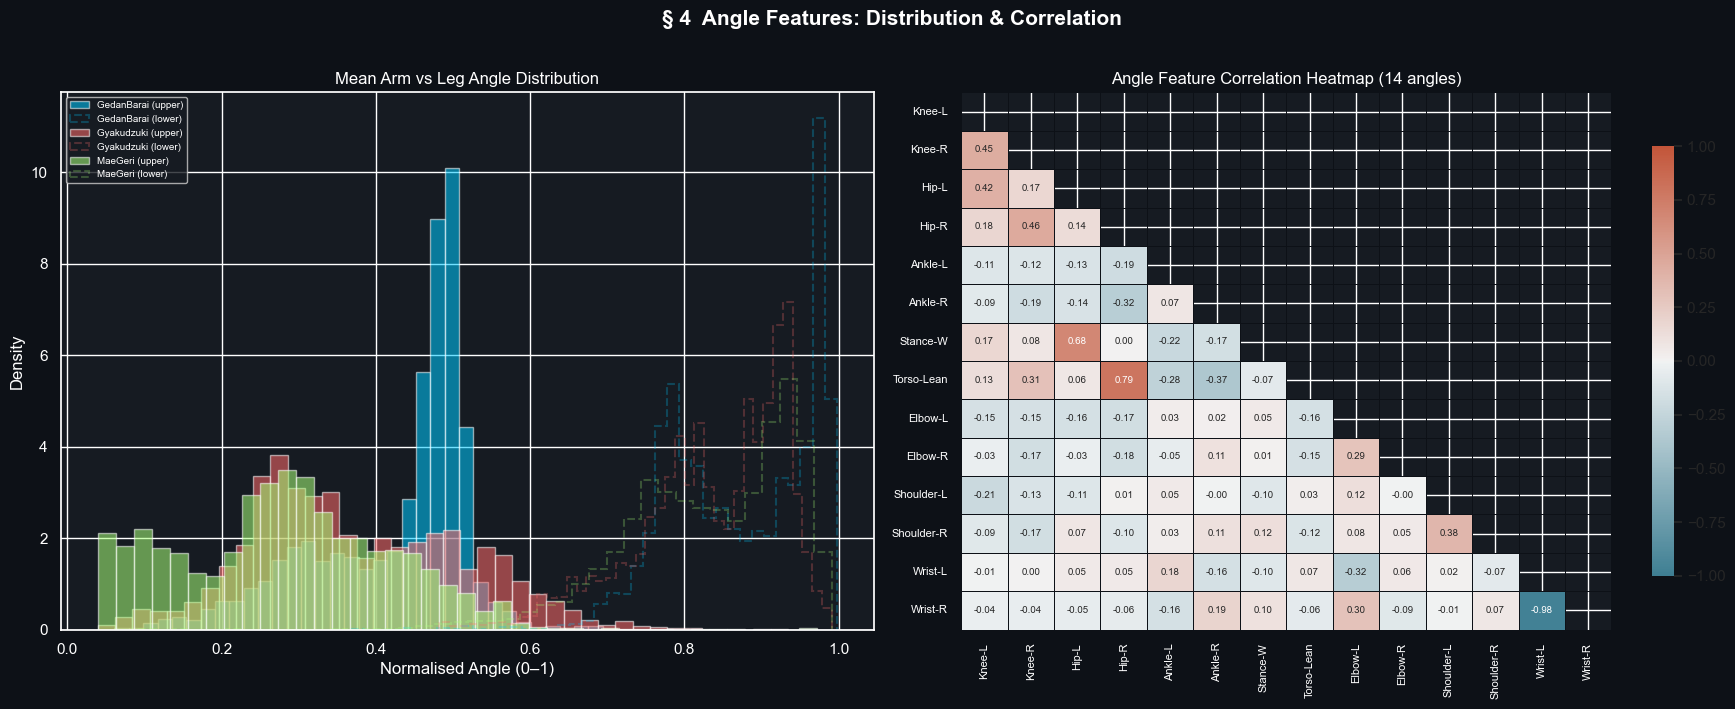


🔗 High-correlation angle pairs (|r| > 0.7):
Wrist-R     Wrist-L    0.979960
Torso-Lean  Hip-R      0.793585
dtype: float64


In [6]:
ALL_ANGLES = [f'angle_{i:02d}' for i in range(14)]
angle_labels = {
    'angle_00': 'Knee-L',  'angle_01': 'Knee-R',
    'angle_02': 'Hip-L',   'angle_03': 'Hip-R',
    'angle_04': 'Ankle-L', 'angle_05': 'Ankle-R',
    'angle_06': 'Stance-W','angle_07': 'Torso-Lean',
    'angle_08': 'Elbow-L', 'angle_09': 'Elbow-R',
    'angle_10': 'Shoulder-L','angle_11':'Shoulder-R',
    'angle_12': 'Wrist-L', 'angle_13': 'Wrist-R'
}

angle_df = df[ALL_ANGLES].copy().rename(columns=angle_labels)
corr = angle_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG_COLOR)
fig.suptitle('§ 4  Angle Features: Distribution & Correlation', fontsize=15,
             fontweight='bold', color='white', y=1.01)

# ─ KDE distributions per class ──────────────────────────────────────────────
for cls, clr in PALETTE.items():
    sub = df[df['folder_label'] == cls]
    mean_upper = sub[['angle_08','angle_09','angle_10','angle_11']].mean(axis=1)
    mean_lower = sub[['angle_00','angle_01','angle_02','angle_03']].mean(axis=1)
    axes[0].hist(mean_upper, bins=40, alpha=0.55, color=clr, label=f'{cls} (upper)', density=True)
    axes[0].hist(mean_lower, bins=40, alpha=0.25, color=clr, label=f'{cls} (lower)', density=True,
                 linestyle='dashed', histtype='step', linewidth=1.5)
axes[0].set_title('Mean Arm vs Leg Angle Distribution', color='white')
axes[0].set_xlabel('Normalised Angle (0–1)', color='white')
axes[0].set_ylabel('Density', color='white')
axes[0].tick_params(colors='white')
axes[0].legend(fontsize=7, facecolor='#161B22', labelcolor='white')

# ─ Heatmap ──────────────────────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0,
    center=0, annot=True, fmt='.2f', linewidths=0.4,
    linecolor='#0D1117', ax=axes[1],
    annot_kws={'size': 7}, cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Angle Feature Correlation Heatmap (14 angles)', color='white')
axes[1].tick_params(colors='white', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sec4_angle_distributions.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# High-correlation pairs
print('\n🔗 High-correlation angle pairs (|r| > 0.7):')
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlations
high = corr_pairs[corr_pairs > 0.7].drop_duplicates()
print(high.head(10) if not high.empty else '   None found — angles are well-decorrelated ✅')

## § 5 — Per-Class Temporal Trajectory

Karate techniques are **dynamic actions**, not static poses. This section plots how key joint angles evolve across the 30-frame downsampled window.

- **Upper body** (elbow angles 08 & 09): expect a sharp rise/fall for punches and blocks.
- **Lower body** (knee angles 00 & 01): expect a prominent peak for kicks (MaeGeri), and relative flatness for blocks (GedanBarai) and punches (Gyakudzuki).
- The **vertical dashed line at frame 15** marks the clip midpoint — useful for identifying which technique phase (preparation vs execution vs retraction) drives most of the signal.
- The **shaded band** represents ± 1 standard deviation across clips, showing within-class consistency.

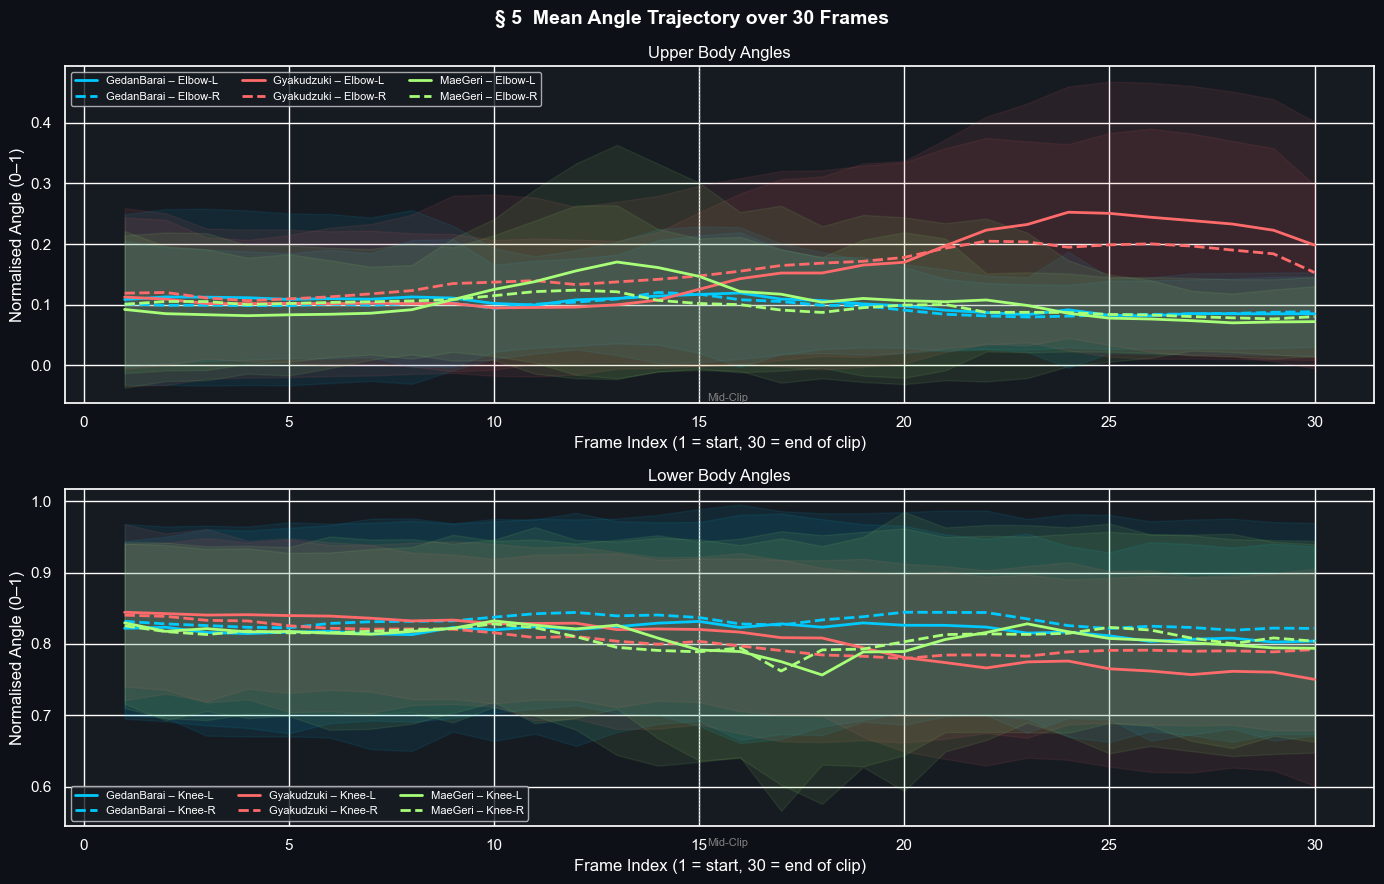

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), facecolor=BG_COLOR)
fig.suptitle('§ 5  Mean Angle Trajectory over 30 Frames', fontsize=14, fontweight='bold', color='white')

representative = {'Upper': ['angle_08','angle_09'], 'Lower': ['angle_00','angle_01']}

for ax, (track, angles) in zip(axes, representative.items()):
    for cls, clr in PALETTE.items():
        sub = df[df['folder_label'] == cls]
        for a, ls in zip(angles, ['-', '--']):
            mean_traj = sub.groupby('frame_idx')[a].mean()
            std_traj  = sub.groupby('frame_idx')[a].std()
            frames    = mean_traj.index
            ax.plot(frames, mean_traj, color=clr, linestyle=ls, linewidth=2,
                    label=f'{cls} – {angle_labels.get(a, a)}')
            ax.fill_between(frames, mean_traj - std_traj, mean_traj + std_traj,
                            color=clr, alpha=0.08)
    ax.set_title(f'{track} Body Angles', color='white')
    ax.set_xlabel('Frame Index (1 = start, 30 = end of clip)', color='white')
    ax.set_ylabel('Normalised Angle (0–1)', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8, facecolor='#161B22', labelcolor='white', ncol=3)
    ax.axvline(x=15, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.text(15.2, ax.get_ylim()[0]*0.95, 'Mid-Clip', color='gray', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sec5_temporal_trajectory.png'), dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

## § 6 — Summary & Dataset Readiness Report

A concise checklist verifying the dataset is fit for Dual-Stem training:

- Correct row/clip counts and frame counts per clip.
- Matching feature counts to the model's expected input shapes (54 upper, 48 lower).
- Zero missing or infinite values.
- Visual class-balance bar.

In [8]:
print('=' * 60)
print('  DATASET READINESS REPORT')
print('=' * 60)

unique_clips = df['clip_id'].nunique()
print(f'  Total Frames      : {len(df):,}')
print(f'  Total Clips       : {unique_clips}')
print(f'  Frames / Clip     : {len(df) // unique_clips}  (expected: 30)')
print(f'  Upper Features    : {len(UPPER_FEATS)}  (target: 54)')
print(f'  Lower Features    : {len(LOWER_FEATS)}  (target: 48)')
print(f'  Missing Values    : {df.isnull().sum().sum()}')
print(f'  Infinite Values   : {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}')
print()
print('  Class distribution (clip level):')
for _, row in clip_balance.iterrows():
    bar = '█' * int(row['pct'] / 2)
    print(f"    {row['folder_label']:<14} {row['num_clips']:>4} clips  {bar}  {row['pct']}%")
print()
print('  ✅  Dataset is READY for Dual-Stem Fusion Training')
print('=' * 60)

  DATASET READINESS REPORT
  Total Frames      : 13,380
  Total Clips       : 446
  Frames / Clip     : 30  (expected: 30)
  Upper Features    : 54  (target: 54)
  Lower Features    : 48  (target: 48)
  Missing Values    : 0
  Infinite Values   : 0

  Class distribution (clip level):
    MaeGeri         175 clips  ███████████████████  39.2%
    Gyakudzuki      142 clips  ███████████████  31.8%
    GedanBarai      129 clips  ██████████████  28.9%

  ✅  Dataset is READY for Dual-Stem Fusion Training
